In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from scipy.stats import chi2_contingency
import statsmodels.api as sm

df = pd.read_csv('C:/Users/prajw/Downloads/train_u6lujuX_CVtuZ9i (1).csv')

In [2]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
df.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
613,LP002990,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


In [5]:
df.shape

(614, 13)

In [6]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [7]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [9]:
df.dropna(inplace=True)
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})  # 1 = Approved, 0 = Not Approved
df['Married'] = df['Married'].map({'Yes': 1, 'No': 0})
df['Education'] = df['Education'].map({'Graduate': 1, 'Not Graduate': 0})
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df['Self_Employed'] = df['Self_Employed'].map({'Yes': 1, 'No': 0})
df['Property_Area'] = df['Property_Area'].map({'Urban': 2, 'Semiurban': 1, 'Rural': 0})


In [10]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,2,1
3,LP001006,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,2,1
4,LP001008,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,2,1
5,LP001011,1,1,2,1,1,5417,4196.0,267.0,360.0,1.0,2,1


In [11]:
bins = [0, 3000, 5000, np.inf]
labels = ['Low', 'Medium', 'High']
df['Income_Level'] = pd.cut(df['ApplicantIncome'], bins=bins, labels=labels)

print("Data loaded and preprocessed. Shape:", df.shape)

Data loaded and preprocessed. Shape: (480, 14)


In [12]:
# Step 2: SQL Equivalent - Count of Approved Loans by Income Level
approved_counts = df[df['Loan_Status'] == 1].groupby('Income_Level').size()
print("\nApproved Loans by Income Level:")
print(approved_counts)


Approved Loans by Income Level:
Income_Level
Low        94
Medium    133
High      105
dtype: int64


C:\Users\prajw\AppData\Local\Temp\ipykernel_14500\2947755196.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  approved_counts = df[df['Loan_Status'] == 1].groupby('Income_Level').size()


In [13]:
# Step 3: Descriptive Stats - Income and Loan Amount Summary
income_summary = df['ApplicantIncome'].describe()
loan_summary = df['LoanAmount'].describe()
print("\nIncome Summary:")
print(income_summary)
print("\nLoan Amount Summary:")
print(loan_summary)


Income Summary:
count      480.000000
mean      5364.231250
std       5668.251251
min        150.000000
25%       2898.750000
50%       3859.000000
75%       5852.500000
max      81000.000000
Name: ApplicantIncome, dtype: float64

Loan Amount Summary:
count    480.000000
mean     144.735417
std       80.508164
min        9.000000
25%      100.000000
50%      128.000000
75%      170.000000
max      600.000000
Name: LoanAmount, dtype: float64


In [14]:
# Step 4: Logistic Regression - Predict Loan Approval Probability
features = ['ApplicantIncome', 'LoanAmount', 'Credit_History', 'Married', 'Education']
X = df[features]
y = df['Loan_Status']
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# Train model
model = LogisticRegression()
model.fit(X_train, y_train)
# Predict probabilities and classes
y_pred_prob = model.predict_proba(X_test)[:, 1]  # Probability of approval
y_pred = model.predict(X_test)
# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f"\nLogistic Regression Accuracy: {accuracy:.2f}")
print("Sample Predicted Probabilities (first 5):", y_pred_prob[:5])
# Optional: Coefficients for interpretation
coeff_df = pd.DataFrame(model.coef_[0], index=features, columns=['Coefficient'])
print("\nModel Coefficients:")
print(coeff_df)


Logistic Regression Accuracy: 0.80
Sample Predicted Probabilities (first 5): [0.85027788 0.72612058 0.77306808 0.24166966 0.82604611]

Model Coefficients:
                 Coefficient
ApplicantIncome     0.000014
LoanAmount         -0.003530
Credit_History      2.809363
Married             0.638799
Education           0.057466


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [15]:
# Step 5: Inferential Stats - Chi-Square Test Between Loan Status & Marital Status
contingency_table = pd.crosstab(df['Married'], df['Loan_Status'])
print("\nContingency Table (Married vs Loan_Status):")
print(contingency_table)

chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi2 Statistic: {chi2:.2f}, p-value: {p:.4f}")
if p < 0.05:
    print("Significant association: Marital status affects loan approval.")
else:
    print("No significant association.")


Contingency Table (Married vs Loan_Status):
Loan_Status   0    1
Married             
0            64  105
1            84  227
Chi2 Statistic: 5.56, p-value: 0.0184
Significant association: Marital status affects loan approval.


([<matplotlib.axis.XTick at 0x274f79a8ad0>,
 [Text(0, 0, 'Not Approved'), Text(1, 0, 'Approved')])

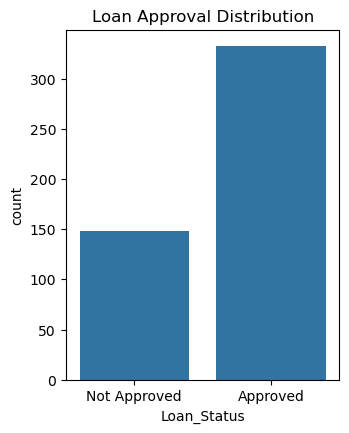

In [16]:
# Step 6: Visualizations
plt.figure(figsize=(12, 10))
# Countplot: Loan Approval Distribution
plt.subplot(2, 3, 1)
sns.countplot(x='Loan_Status', data=df)
plt.title('Loan Approval Distribution')
plt.xticks([0, 1], ['Not Approved', 'Approved'])

C:\Users\prajw\AppData\Local\Temp\ipykernel_14500\4126561597.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  approval_rate = df.groupby('Income_Level')['Loan_Status'].mean()


Text(0, 0.5, 'Approval Rate')

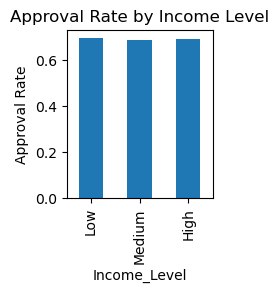

In [17]:
# Bar Chart: Income vs Loan Approval Rate
plt.subplot(2, 3, 2)
approval_rate = df.groupby('Income_Level')['Loan_Status'].mean()
approval_rate.plot(kind='bar')
plt.title('Approval Rate by Income Level')
plt.ylabel('Approval Rate')

Text(0.5, 1.0, 'Correlation Matrix')

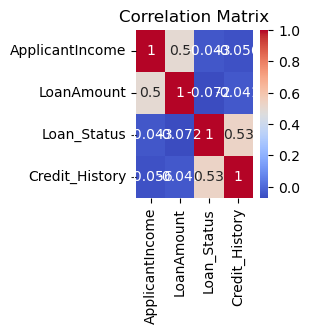

In [18]:
# Heatmap: Correlation Matrix
plt.subplot(2, 3, 3)
numeric_df = df[['ApplicantIncome', 'LoanAmount', 'Loan_Status', 'Credit_History']]
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')


([<matplotlib.axis.XTick at 0x274f7cd9950>,
 [Text(0, 0, 'Not Graduate'), Text(1, 0, 'Graduate')])

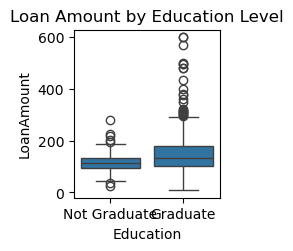

In [19]:
# Boxplot: Loan Amount by Education Level
plt.subplot(2, 3, 4)
sns.boxplot(x='Education', y='LoanAmount', data=df)
plt.title('Loan Amount by Education Level')
plt.xticks([0, 1], ['Not Graduate', 'Graduate'])


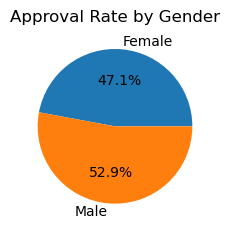


All tasks completed. Visualizations displayed.


In [20]:
# Pie Chart: Loan Approval by Gender
plt.subplot(2, 3, 5)
approval_by_gender = df.groupby('Gender')['Loan_Status'].mean()
labels = ['Female', 'Male']
plt.pie(approval_by_gender, labels=labels, autopct='%1.1f%%')
plt.title('Approval Rate by Gender')

plt.tight_layout()
plt.show()

print("\nAll tasks completed. Visualizations displayed.")

In [6]:
import pandas as pd

# Load dataset
df = pd.read_csv('C:/Users/prajw/Downloads/train_u6lujuX_CVtuZ9i (1).csv')

# Create total Income column (Applicant + Coapplicant)
df['Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']

# Descriptive statistics for Income and Loan Amount
income_summary = df['Income'].describe()
loan_summary = df['LoanAmount'].describe()

print("Income Summary:\n", income_summary)
print("\nLoan Amount Summary:\n", loan_summary)


Income Summary:
 count      614.000000
mean      7024.705081
std       6458.663872
min       1442.000000
25%       4166.000000
50%       5416.500000
75%       7521.750000
max      81000.000000
Name: Income, dtype: float64

Loan Amount Summary:
 count    592.000000
mean     146.412162
std       85.587325
min        9.000000
25%      100.000000
50%      128.000000
75%      168.000000
max      700.000000
Name: LoanAmount, dtype: float64


In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
df = pd.read_csv('C:/Users/prajw/Downloads/train_u6lujuX_CVtuZ9i (1).csv')

# Prepare data
df['Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']
df['Dependents'].replace('3+', 3, inplace=True)
df['Dependents'] = df['Dependents'].astype(float)

# Fill missing values
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].median(), inplace=True)

# Encode target variable
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N_]()_]()


SyntaxError: unterminated string literal (detected at line 20) (2293039449.py, line 20)

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
df = pd.read_csv('C:/Users/prajw/Downloads/train_u6lujuX_CVtuZ9i (1).csv')

# Prepare data
df['Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']
df['Dependents'].replace('3+', 3, inplace=True)
df['Dependents'] = df['Dependents'].astype(float)

# Fill missing values
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].median(), inplace=True)

# Encode target variable
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

# Feature and target selection
X = df[['Income', 'LoanAmount', 'Credit_History', 'Dependents']]
y = df['Loan_Status']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


C:\Users\prajw\AppData\Local\Temp\ipykernel_18352\160766625.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Dependents'].replace('3+', 3, inplace=True)
C:\Users\prajw\AppData\Local\Temp\ipykernel_18352\160766625.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exam

Accuracy: 0.7804878048780488

Confusion Matrix:
 [[18 25]
 [ 2 78]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.42      0.57        43
           1       0.76      0.97      0.85        80

    accuracy                           0.78       123
   macro avg       0.83      0.70      0.71       123
weighted avg       0.81      0.78      0.75       123



In [10]:
import pandas as pd

# Load dataset
df = pd.read_csv('C:/Users/prajw/Downloads/train_u6lujuX_CVtuZ9i (1).csv')

# Let's assume we define income levels based on ApplicantIncome
# You can adjust bins as needed
bins = [0, 4000, 7000, float('inf')]
labels = ['Low', 'Medium', 'High']
df['Income_Level'] = pd.cut(df['ApplicantIncome'], bins=bins, labels=labels)

# Filter only approved loans
approved_loans = df[df['Loan_Status'] == 'Y']

# Group by Income_Level and count
result = approved_loans.groupby('Income_Level').size().reset_index(name='Approved_Loan_Count')

# Sort descending by count
result = result.sort_values(by='Approved_Loan_Count', ascending=False)

print(result)


  Income_Level  Approved_Loan_Count
0          Low                  233
1       Medium                  117
2         High                   72


C:\Users\prajw\AppData\Local\Temp\ipykernel_18352\1197832221.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = approved_loans.groupby('Income_Level').size().reset_index(name='Approved_Loan_Count')
